# Cavity Flow (Steady) — Stream-Function Form

This notebook recreates [`examples/cavity_flow_steady`](../../examples/cavity_flow_steady/cavity_flow_steady.ipynb) using the new **stream-function** formulation of the incompressible Navier–Stokes equations.

Instead of learning the velocity and pressure fields `(u, v, p)` directly, the network learns the **stream function** `psi` and the pressure `p`, and the velocity is derived as

$$u = \frac{\partial \psi}{\partial y}, \qquad v = -\frac{\partial \psi}{\partial x}.$$

Because the velocity is derived from a single scalar, the incompressibility constraint $\nabla \cdot \mathbf{u} = 0$ is satisfied **identically**, so the `StreamFunctionNavierStokes` PDE contributes only the two momentum residuals. The setup follows the classic lid-driven cavity benchmark.

In [1]:
import os
import sys
import pathlib

import numpy as np
import torch

# Make the package importable when running from this experiment folder
_PROJECT_ROOT = pathlib.Path(os.getcwd()).resolve()
for _parent in _PROJECT_ROOT.parents:
    if (_parent / "src" / "deepflow").is_dir():
        sys.path.insert(0, str(_parent / "src"))
        break

import deepflow as df

df.device = "cpu"            # use "cuda" if a GPU is available
df.manual_seed(69)           # for reproducibility
print("DeepFlow is running on:", df.device)

# Output directory for figures and model checkpoint
OUT_DIR = pathlib.Path(os.getcwd()) / "output"
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("Output directory:", OUT_DIR)

DeepFlow is running on: cpu
Output directory: c:\Users\thamm\OneDrive\Documents\1 - Projects\0 - STEM\2 - Numerical Physics\9 - PINNs\pinn-deepflow\EXPERIMENTS\cavity_flow_streamfunction\output


## 2. Set Physical and Numerical Parameters

We keep the exact physical setup of the original `cavity_flow_steady` example. The lid moves at $U=10^{-4}$ m/s over a $1\times1$ m cavity filled with water ($\rho=1000$ kg/m³, $\mu=0.001$ Pa·s), giving a cavity Reynolds number

$$Re=\frac{\rho U L}{\mu}=100.$$

In the non-dimensional stream-function problem the domain is $[0,1]\times[0,1]$ and the reference velocity is the lid speed, so the lid boundary condition becomes $u=1 \Leftrightarrow \psi_y=1$.

In [2]:
# Physical parameters (dimensional)
rho = 1000.0      # density
mu = 0.001        # dynamic viscosity
U = 0.0001        # lid velocity (reference velocity scale)
L = 1.0           # cavity length (reference length scale)

# Numerical / network parameters (same as the original example)
WIDTH = 50
DEPTH = 5
LEARNING_RATE = 0.004
ADAM_EPOCHS = 500
LBFGS_EPOCHS = 250
THRESHOLD_ADAM = 0.005
THRESHOLD_LBFGS = 0.0001

BOUND_RES = [1000, 1000, 1000, 1000, 10]   # walls + pressure reference point
AREA_RES = [2000]                           # interior collocation points

## 3. Build Stream-Function Network

As in the original example we build a fully-connected `PINN` with `tanh` activations. The only difference is the output layer: the network now emits **two** fields `psi` and `p` (stream function + pressure) instead of three velocity/pressure fields.

| Quantity | Original `(u, v, p)` | Stream-function `(psi, p)` |
|---|---|---|
| Network outputs | `['u', 'v', 'p']` | `['psi', 'p']` |
| Velocities | direct outputs | $u=\psi_y$, $v=-\psi_x$ |
| Continuity | residual equation | satisfied identically |

In [3]:
model = df.PINN(
    width=WIDTH,
    length=DEPTH,
    input_vars=["x", "y"],
    output_vars=["psi", "p"],
)
print("Model output fields:", model.output_keys)

Model output fields: ['psi', 'p']


## 4. Instantiate the Stream-Function Navier–Stokes PDE

We attach the new `StreamFunctionNavierStokes` PDE to the cavity area. It uses the same parameters as `NavierStokes` and computes the two steady momentum residuals

$$R_x = uu_x + vu_y + p_x - \frac{1}{Re}\nabla^2 u, \qquad
R_y = uv_x + vv_y + p_y - \frac{1}{Re}\nabla^2 v,$$

with $u=\psi_y$, $v=-\psi_x$ and $Re=\rho U L/\mu$. Since this formulation is **steady**, only `x` and `y` coordinates are supplied (no `t`).

In [4]:
pde = df.StreamFunctionNavierStokes(mu=mu, rho=rho, U=U, L=L)
print("Reynolds number Re =", pde.Re)

# Sanity check: the formulation is steady-only; passing a time input must fail.
try:
    pde.compute_residuals({"x": torch.zeros(4), "y": torch.zeros(4),
                           "t": torch.zeros(4), "psi": torch.zeros(4),
                           "p": torch.zeros(4)})
except ValueError as exc:
    print("As expected, time inputs are rejected:", exc)

Reynolds number Re = 100.0
As expected, time inputs are rejected: StreamFunctionNavierStokes supports steady problems only; remove the 't' input or use NavierStokes.


## 5. Create Collocation and Boundary Points

We reuse the DeepFlow domain machinery exactly as in the original example: a unit-square `Area` plus a pressure reference `point` at the origin.

The lid-driven-cavity boundary conditions are translated from velocity to stream-function form:

| Boundary | Velocity BC | Stream-function BC |
|---|---|---|
| Bottom / right / left walls | $u=0,\ v=0$ | $\psi=0$ (constant wall) |
| Top lid | $u=1,\ v=0$ | $\psi=1$ and $\psi_y=1$ |
| Pressure reference point | $p=0$ | $p=0$ |

A constant stream function along a wall enforces the no-slip condition: the tangential velocity is the wall derivative of $\psi$ (zero) and the normal velocity is also zero because $\psi$ does not vary along the wall. On the lid, $\psi_y=1$ additionally enforces the driven tangential velocity $u=1$.

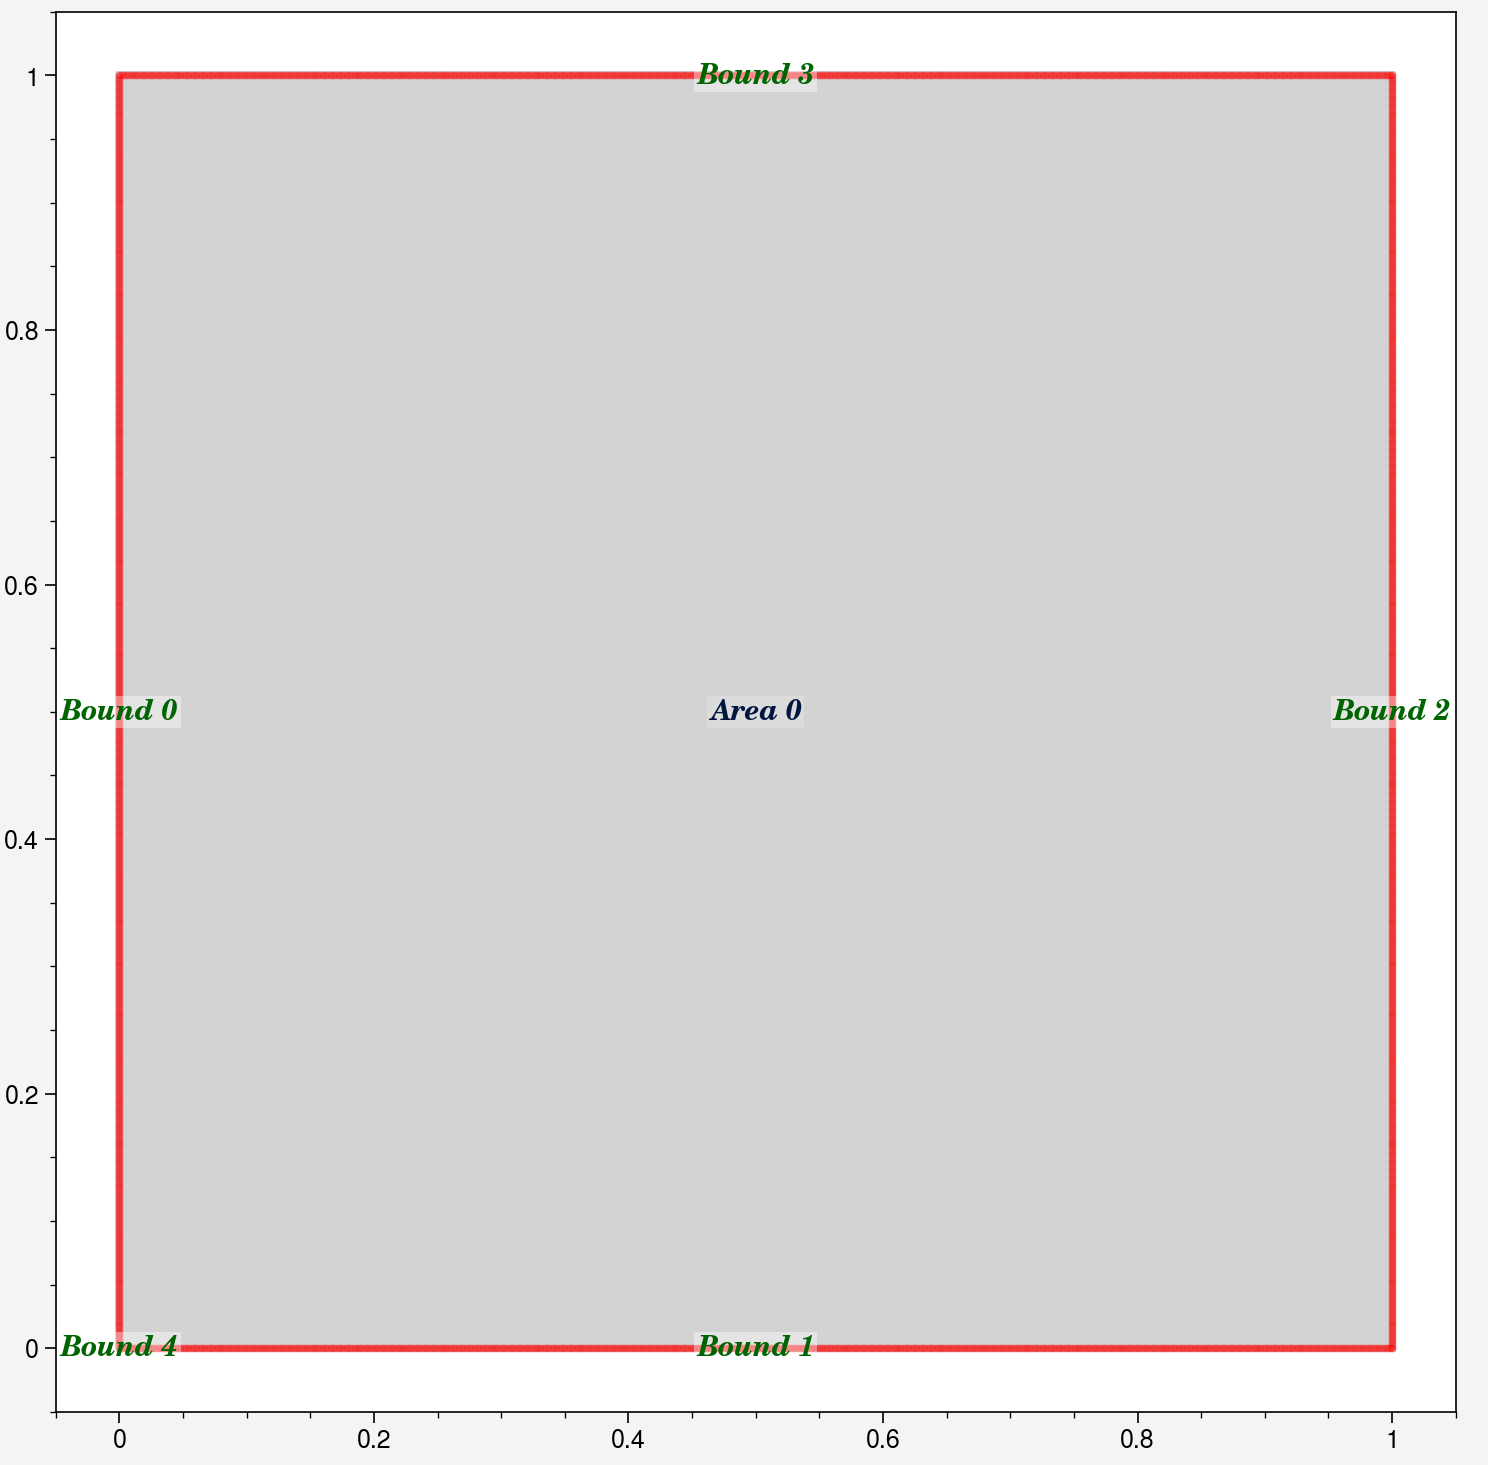

In [5]:
rectangle = df.geometry.rectangle([0, 1], [0, 1])
point = df.geometry.point(0, 0)
domain = df.domain(rectangle, point)
domain.show_setup()

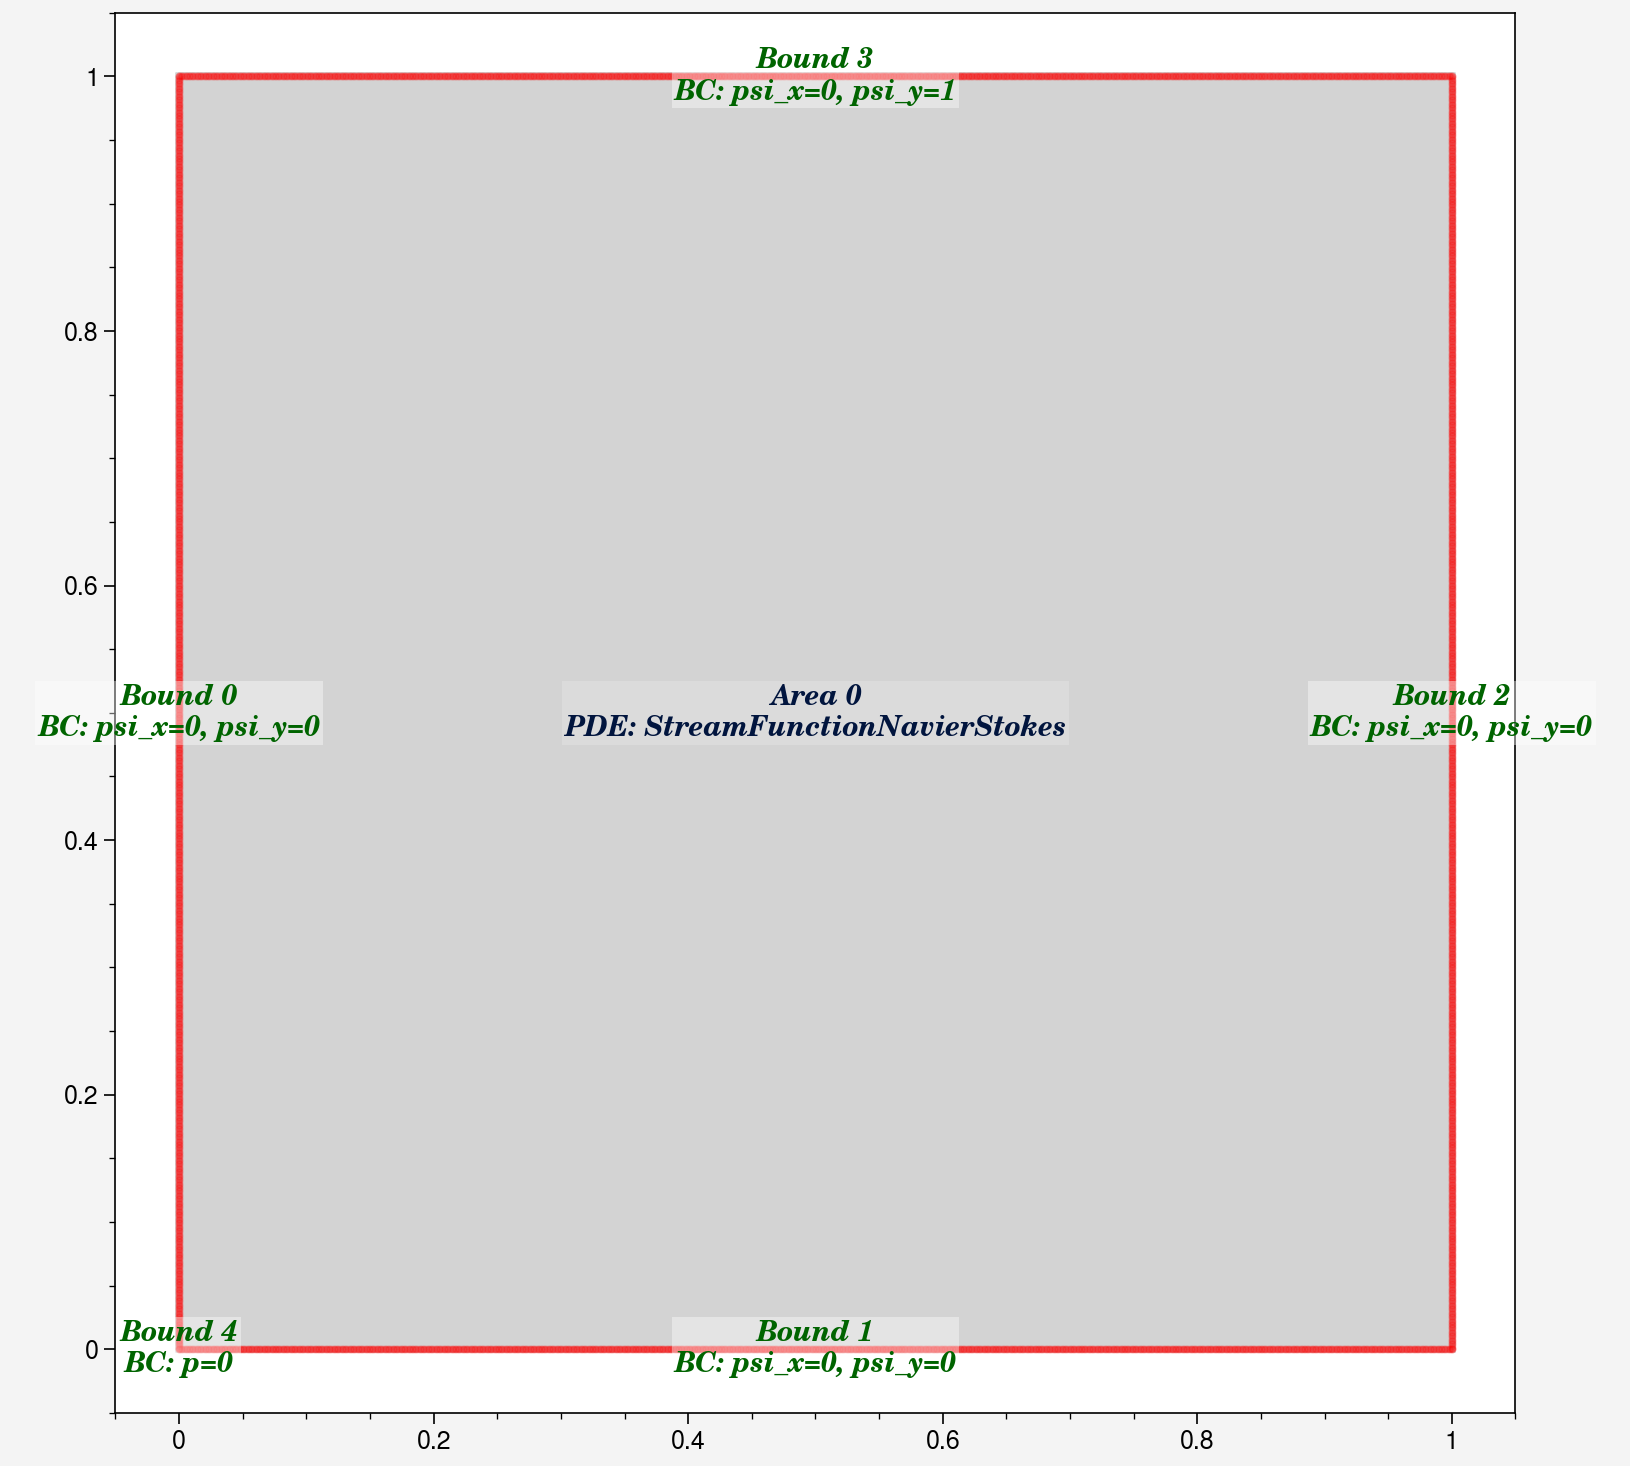

In [6]:
# Wall ordering for rectangle(): 0=left, 1=bottom, 2=right, 3=top.
# Stationary walls: psi=constant enforces impermeability, while the
# tangential derivative enforces zero tangential velocity.
domain.bound_list[0].define_bc({"psi_x": 0, "psi_y": 0})  # left: v = -psi_x = 0
domain.bound_list[1].define_bc({"psi_x": 0, "psi_y": 0})  # bottom: u = psi_y = 0
domain.bound_list[2].define_bc({"psi_x": 0, "psi_y": 0})  # right: v = -psi_x = 0

# Moving top lid: u = psi_y = 1, v = -psi_x = 0.
domain.bound_list[3].define_bc({"psi_x": 0, "psi_y": 1})

# Pressure reference point: pressure is defined up to an additive constant.
domain.bound_list[4].define_bc({"p": 0})

domain.area_list[0].define_pde(pde)
domain.show_setup()

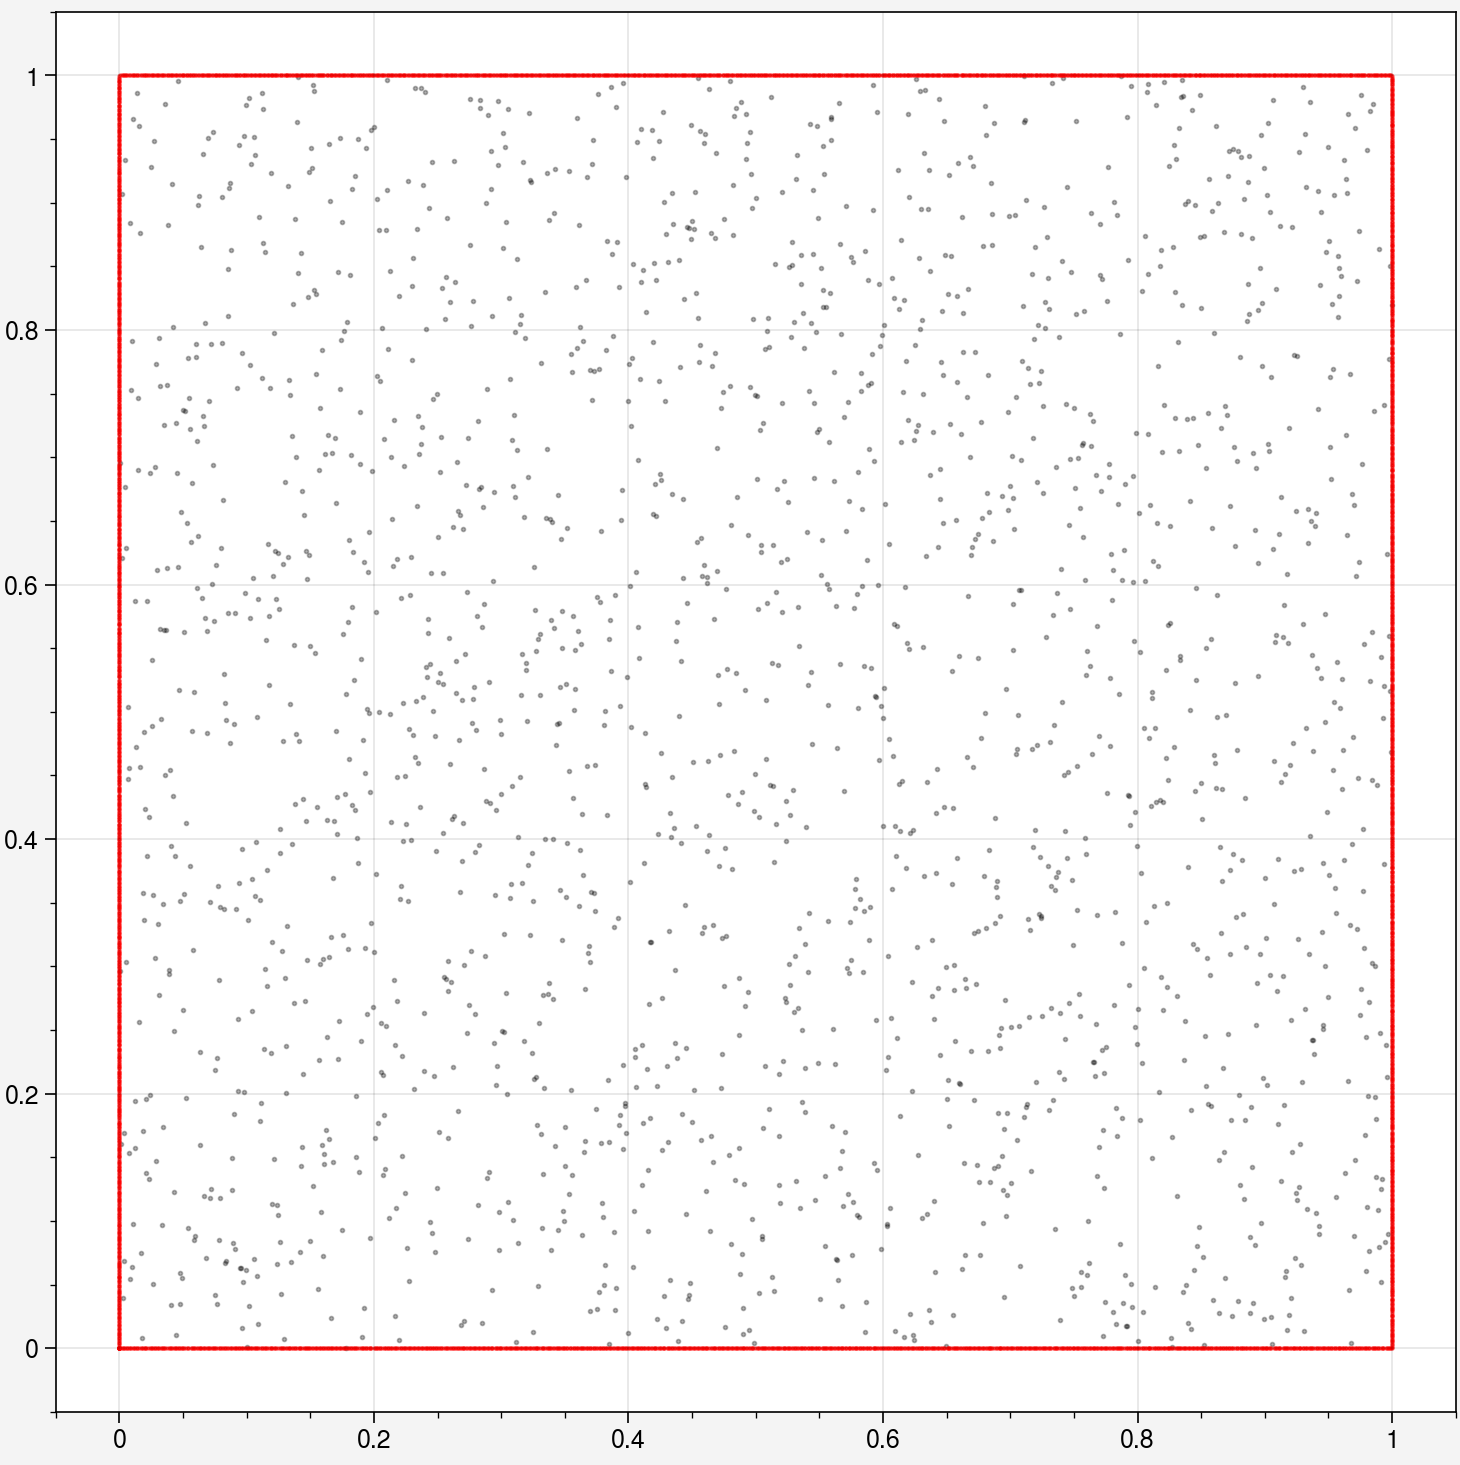

In [7]:
domain.sampling_lhs(
    bound_sampling_res=BOUND_RES,
    area_sampling_res=AREA_RES,
)
domain.show_coordinates(display_physics=False)

## 6. Forward Pass and Residual Computation

The DeepFlow training loop feeds `(x, y)` into the network and passes the model outputs `psi` and `p` (together with the coordinates) to `StreamFunctionNavierStokes.compute_residuals`, which returns the two momentum residuals. The PDE loss is the mean of the squared residuals summed over the two momentum equations.

We verify the derived velocity fields `u = psi_y` and `v = -psi_x` are consistent with the PDE's internal computation.

In [8]:
def derive_velocity(psi: torch.Tensor, x: torch.Tensor, y: torch.Tensor):
    """Derive velocity from the stream function: u = psi_y, v = -psi_x.

    Differentiate w.r.t. the original coordinate leaf tensors (not slices),
    which keeps the higher-order autograd graph intact.
    """
    psi_x = torch.autograd.grad(psi, x, grad_outputs=torch.ones_like(psi),
                                create_graph=True, retain_graph=True)[0]
    psi_y = torch.autograd.grad(psi, y, grad_outputs=torch.ones_like(psi),
                                create_graph=True, retain_graph=True)[0]
    return psi_y, -psi_x


# Probe the internal residual computation on the interior collocation points.
# The network is evaluated on the full coordinate leaves and the same full
# tensors are passed to the PDE (exactly like the training pipeline).
probe = domain.area_list[0]
out = model({"x": probe.X_, "y": probe.Y_})
u_der, v_der = derive_velocity(out["psi"], probe.X_, probe.Y_)

residuals = pde.compute_residuals(
    {"x": probe.X_, "y": probe.Y_, "psi": out["psi"], "p": out["p"]}
)
print("Number of momentum residuals:", len(residuals))
print("PDE MSE loss on probe:", float(pde.calc_loss().detach()))
print("Derived u matches PDE u:", torch.allclose(u_der, pde.var["u"]))
print("Derived v matches PDE v:", torch.allclose(v_der, pde.var["v"]))


Number of momentum residuals: 2
PDE MSE loss on probe: 0.00037329320912249386
Derived u matches PDE u: True
Derived v matches PDE v: True


## 7. Boundary Loss

The boundary conditions are enforced as a weighted mean-squared-error loss between the predicted and target values of `psi`, `psi_y` (derived from the model output) and `p`. The `define_bc` calls above already attach these conditions to the domain; `calc_loss_simple(domain)` turns them into a soft BC loss that is minimized together with the PDE residual loss.

Because `psi_y` is a **derivative** of the model output, DeepFlow computes it with `torch.autograd.grad(..., create_graph=True)`, so gradients still flow back to the network parameters.

In [9]:
calc_loss = df.calc_loss_simple(domain)

# Sanity check: the combined loss is finite and the BC/pde parts are populated.
loss0 = calc_loss(model)
for key, value in loss0.items():
    value = value.detach() if torch.is_tensor(value) else value
    print(f"Initial {key}: {float(value):.6f}")

Initial pde_loss: 0.000373
Initial bc_loss: 1.007309
Initial ic_loss: 0.000000
Initial total_loss: 1.007682


## 8. Combined Loss and Training

The total loss combines the PDE residual loss and the boundary-condition loss,

$$\mathcal{L} = \mathcal{L}_{\text{pde}} + \mathcal{L}_{\text{bc}},$$

and is minimized exactly like the original example: first with Adam (fast convergence), then refined with L-BFGS (high precision). Residual-based R3 resampling is applied every 100 epochs.

In [10]:
def do_in_adam(epoch, model):
    if epoch % 100 == 0 and epoch > 0:
        domain.sampling_random(bound_sampling_res=BOUND_RES,
                           area_sampling_res=AREA_RES)
        print(domain)


def do_in_lbfgs(epoch, model):
    if epoch % 100 == 0 and epoch > 0:
        domain.sampling_random(bound_sampling_res=BOUND_RES,
                           area_sampling_res=AREA_RES)
        print(domain)


In [11]:
# Phase 1: Adam (fast convergence), same as the original example.
# train_adam returns (model, best_model).
model1, model1best = model.train_adam(
    learning_rate=LEARNING_RATE,
    epochs=ADAM_EPOCHS,
    calc_loss=calc_loss,
    threshold_loss=THRESHOLD_ADAM,
    do_between_epochs=do_in_adam,
)

# Phase 2: L-BFGS refinement (high precision). Also returns (model, best_model).
model2, model2best = model1best.train_lbfgs(
    calc_loss=calc_loss,
    epochs=LBFGS_EPOCHS,
    threshold_loss=THRESHOLD_LBFGS,
    do_between_epochs=do_in_lbfgs,
)
print("Training complete. Final total loss:", model2best.loss_history["total_loss"][-1] if model2best.loss_history["total_loss"] else None)


Epoch: 1, total_loss: 1.00768, bc_loss: 1.00731, pde_loss: 0.00037
number of bound : ['0: 1000', '1: 1000', '2: 1000', '3: 1000', '4: 10']
number of area : ['0: 2000']
Epoch: 200, total_loss: 0.08009, bc_loss: 0.07579, pde_loss: 0.00431
number of bound : ['0: 1000', '1: 1000', '2: 1000', '3: 1000', '4: 10']
number of area : ['0: 2000']
number of bound : ['0: 1000', '1: 1000', '2: 1000', '3: 1000', '4: 10']
number of area : ['0: 2000']
Epoch: 400, total_loss: 0.06537, bc_loss: 0.05823, pde_loss: 0.00713
number of bound : ['0: 1000', '1: 1000', '2: 1000', '3: 1000', '4: 10']
number of area : ['0: 2000']
number of bound : ['0: 1000', '1: 1000', '2: 1000', '3: 1000', '4: 10']
number of area : ['0: 2000']
Epoch: 500, total_loss: 0.08991, bc_loss: 0.08315, pde_loss: 0.00676
Epoch: 501, total_loss: 0.06706, bc_loss: 0.05952, pde_loss: 0.00754
Epoch: 551, total_loss: 0.02748, bc_loss: 0.02233, pde_loss: 0.00515
Epoch: 601, total_loss: 0.01321, bc_loss: 0.01034, pde_loss: 0.00287
number of boun

## 9. Evaluate and Visualize Results

We sample a uniform grid over the cavity, evaluate `psi` and `p`, and derive `u` and `v` from the stream function. The evaluation object exposes all of these fields plus the momentum residuals, so the original example's plots (`v_mag`, `u`, `v`, `p`, streamlines) can be produced unchanged.

In [12]:
df.Visualizer.refwidth_default = 4

# Create the evaluation object and sample a uniform grid.
# Use model2best (the lowest-loss model from L-BFGS refinement).
area_eval = domain.area_list[0].evaluate(model2best)
area_eval.sampling_area([200, 200])
print("Available data keys:", tuple(area_eval.data_dict.keys()))


Available data keys: ('psi', 'p', 'pde_residual', 'x', 'y', 'u', 'v', 'psi_x', 'psi_y', 'u_x', 'u_y', 'v_x', 'v_y', 'p_x', 'p_y', 'continuity_residual', 'x_momentum_residual', 'y_momentum_residual', 'total_loss', 'bc_loss', 'pde_loss')


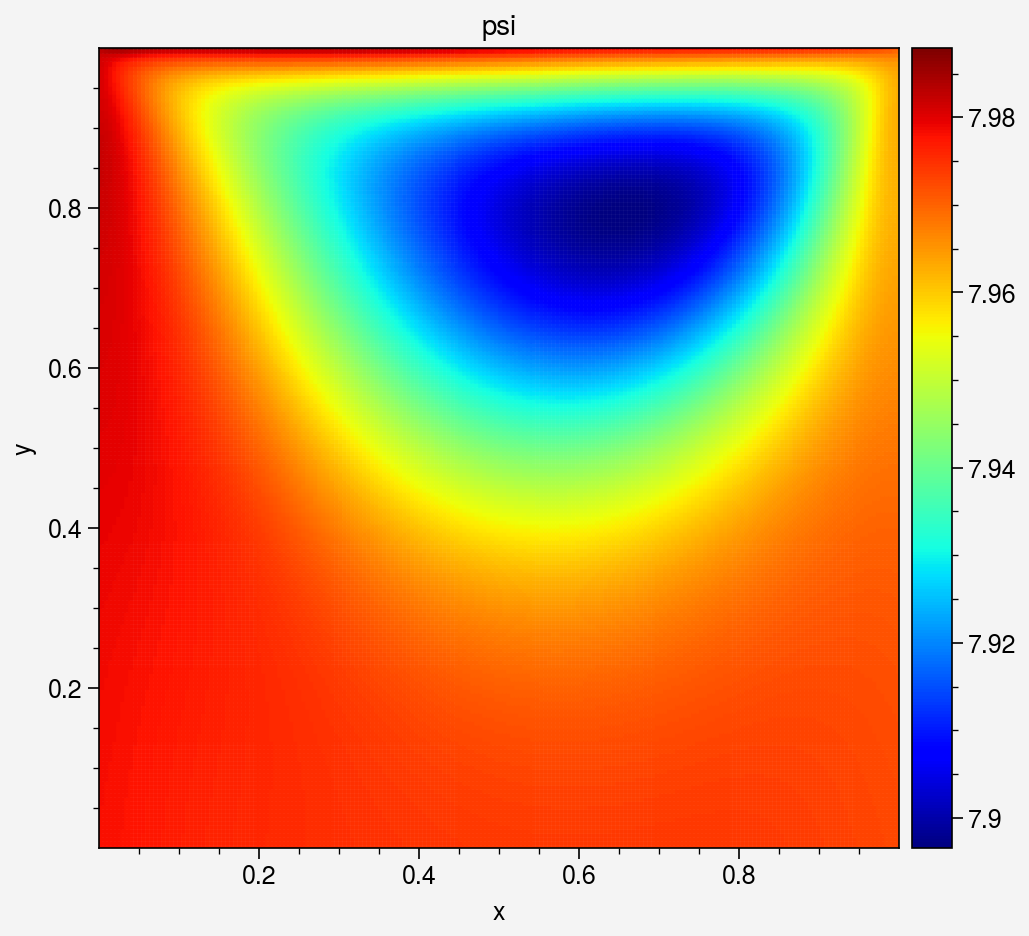

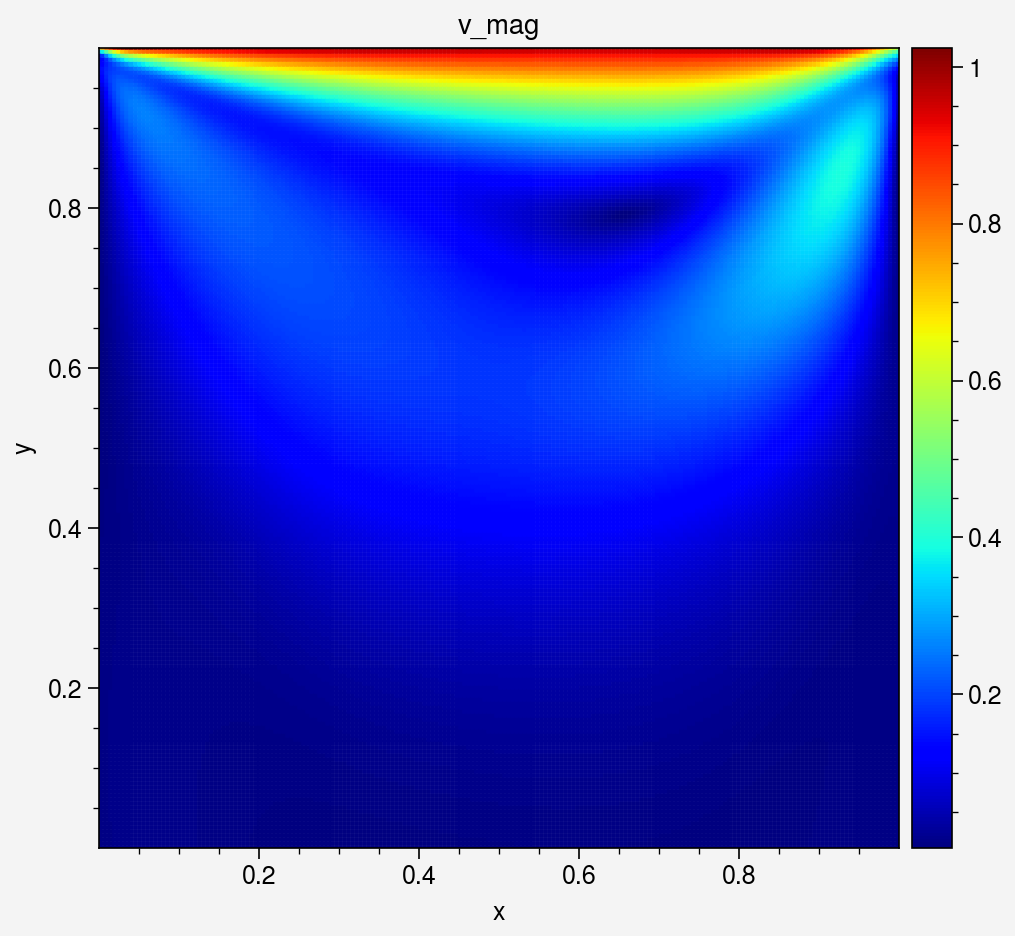

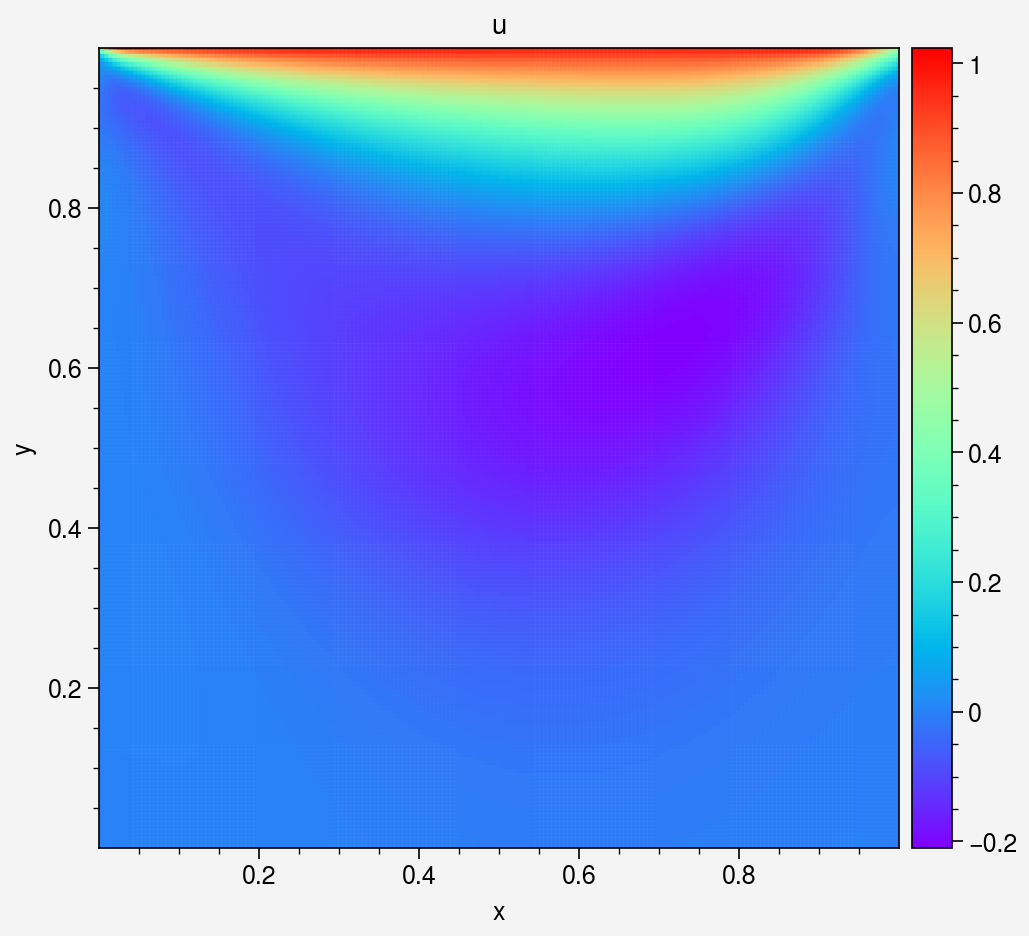

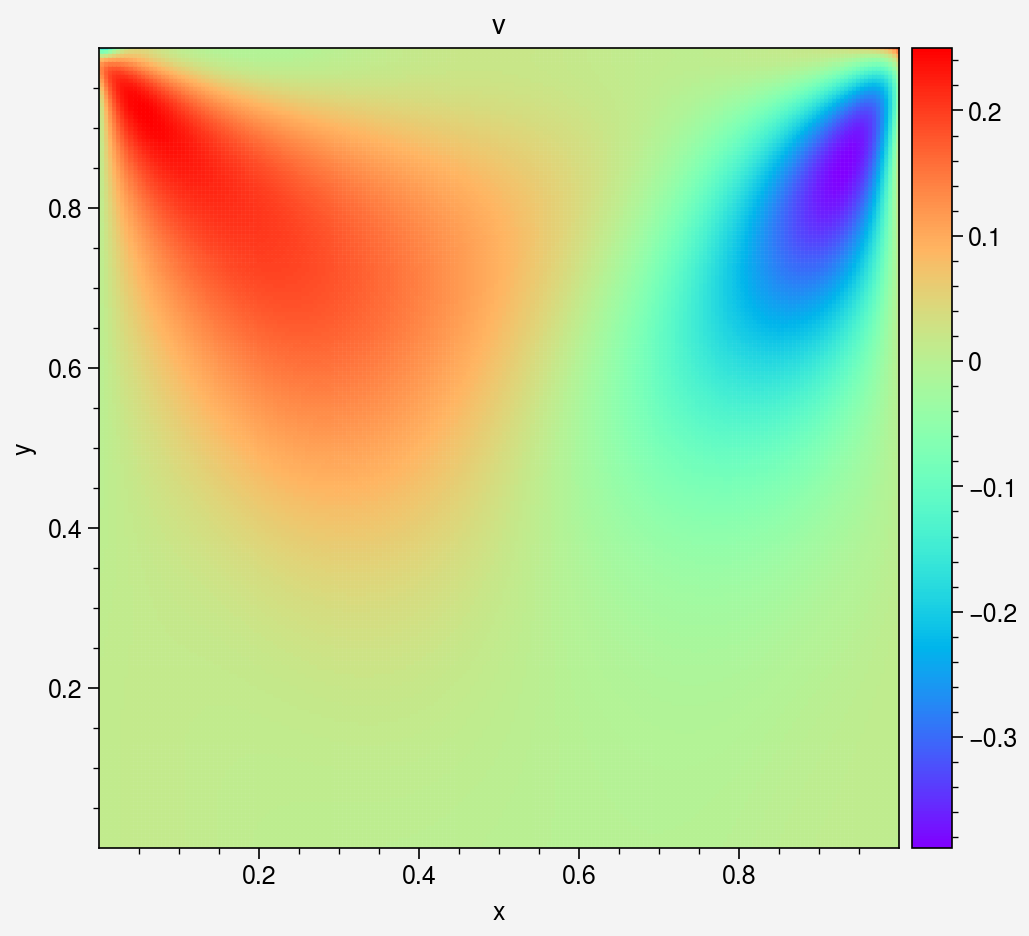

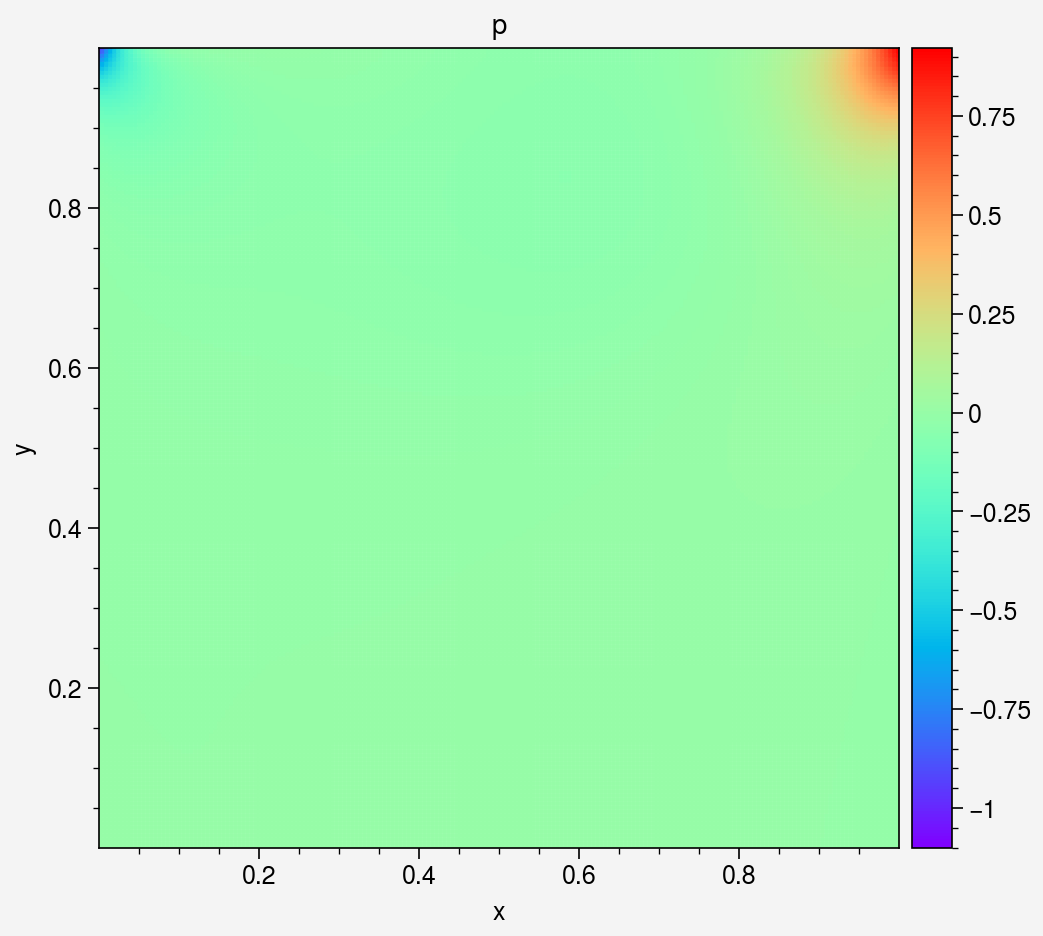

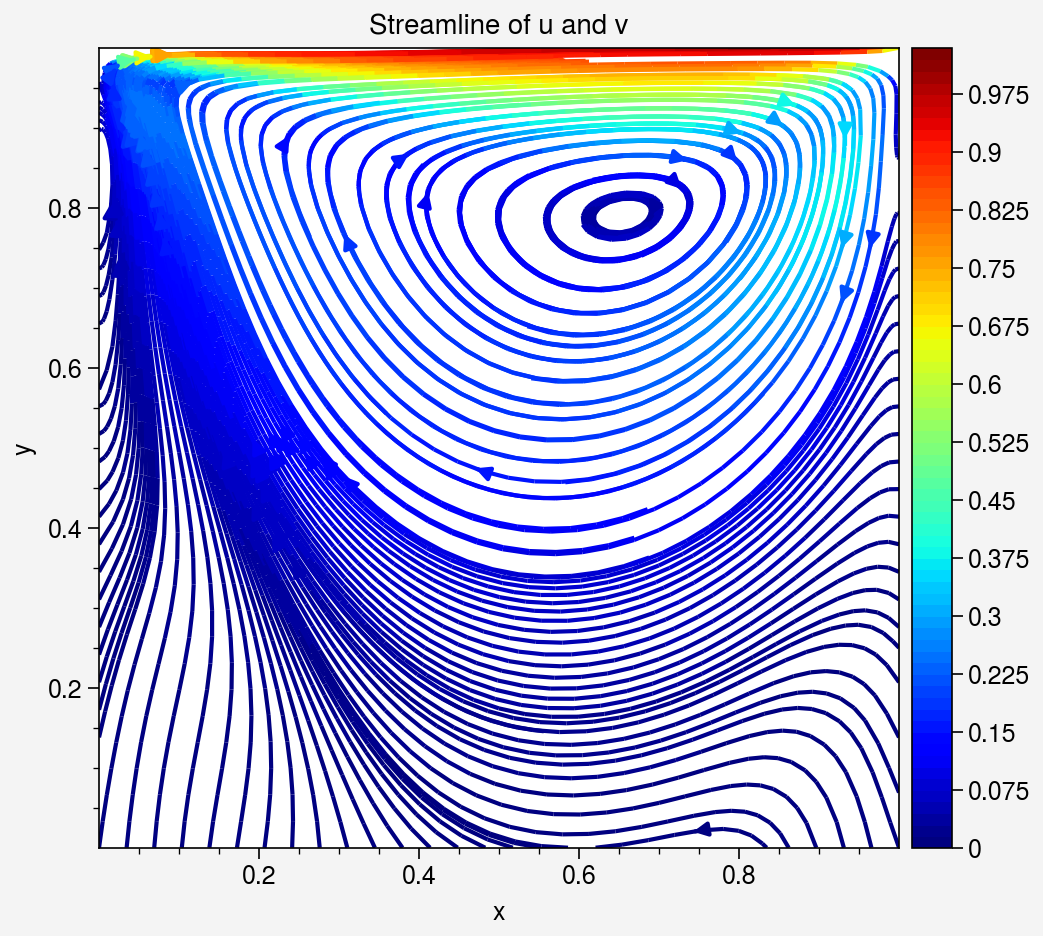

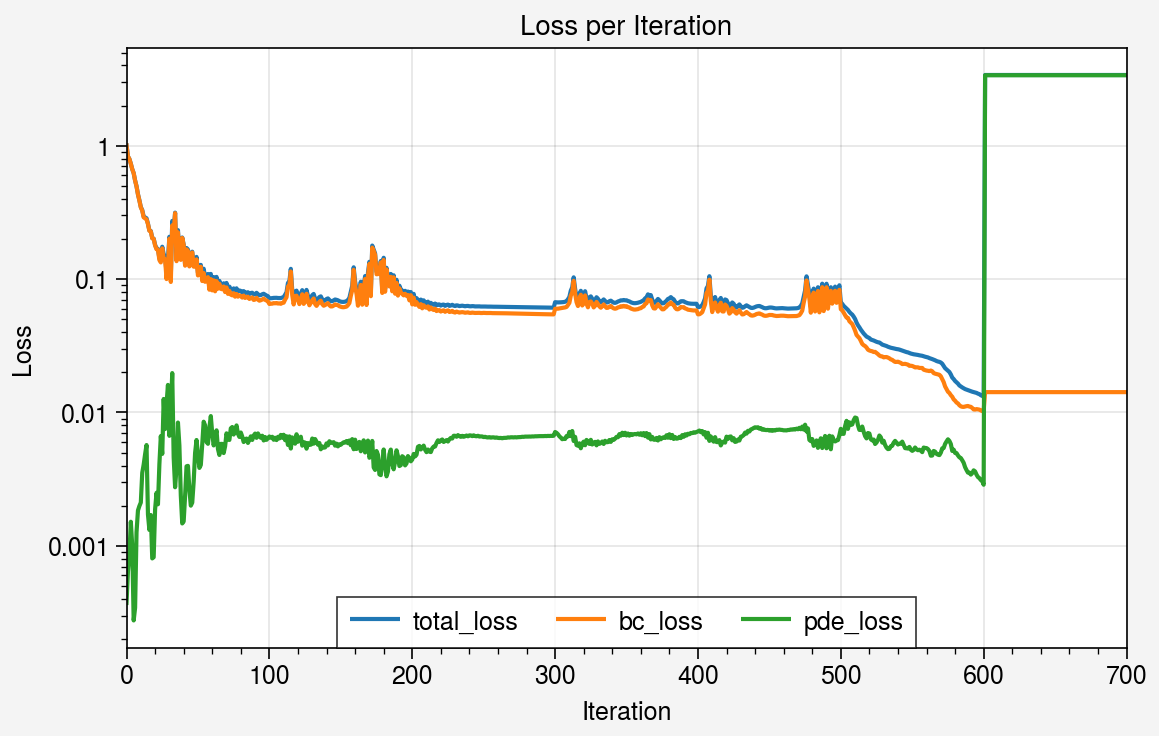

In [13]:
# Velocity magnitude (derived from psi)
area_eval["v_mag"] = (area_eval["u"] ** 2 + area_eval["v"] ** 2) ** 0.5

_ = area_eval.plot_color("psi", s=1.5, cmap="jet").savefig(OUT_DIR / "colorplot_psi.png")
_ = area_eval.plot_color("v_mag", s=1.5, cmap="jet").savefig(OUT_DIR / "colorplot_v_mag.png")
_ = area_eval.plot_color("u", s=1.5, cmap="rainbow")
_ = area_eval.plot_color("v", s=1.5, cmap="rainbow")
_ = area_eval.plot_color("p", s=1.5, cmap="rainbow")
_ = area_eval.plot_streamline("u", "v", cmap="jet")

# Training history
_ = area_eval.plot_loss_curve(log_scale=True)

## 10. Verify Continuity and Compare with the Original Example

Finally we check the key advantage of the stream-function formulation: the continuity residual $u_x + v_y$ must be **approximately zero** everywhere (it is enforced structurally, not by a loss term). We also export the horizontal velocity profile along the vertical centerline $x=0.5$, mirroring the original example's data export, and save the trained model.

In [14]:
# 1) Continuity residual from the PDE evaluation grid
cont = np.asarray(area_eval.data_dict.get("continuity_residual", np.zeros_like(area_eval.data_dict["u"])))
print("Continuity residual: max|u_x + v_y| =", float(np.max(np.abs(cont))))
print("Continuity residual: mean|u_x + v_y| =", float(np.mean(np.abs(cont))))

# 2) Momentum residual magnitudes
x_res = np.asarray(area_eval.data_dict["x_momentum_residual"])
y_res = np.asarray(area_eval.data_dict["y_momentum_residual"])
print("x-momentum residual: mean|Rx| =", float(np.mean(np.abs(x_res))))
print("y-momentum residual: mean|Ry| =", float(np.mean(np.abs(y_res))))

# 3) Export the u-profile along the vertical centerline x = 0.5
x_c = area_eval.data_dict["x"]
y_c = area_eval.data_dict["y"]
u_c = area_eval.data_dict["u"]
mask = np.abs(x_c - 0.5) < 0.5 / 200  # nearest column of the 200x200 grid
centerline = np.column_stack((y_c[mask], u_c[mask]))
np.savetxt(OUT_DIR / "centerline_u.txt", centerline)
print("Saved centerline profile ->", OUT_DIR / "centerline_u.txt")

# 4) Save the model checkpoint
model2best.save_as_pickle(str(OUT_DIR / "model.pkl"))
print("Saved model ->", OUT_DIR / "model.pkl")


Continuity residual: max|u_x + v_y| = 6.0558319091796875e-05
Continuity residual: mean|u_x + v_y| = 3.3994217574218055e-07
x-momentum residual: mean|Rx| = 0.046749770641326904
y-momentum residual: mean|Ry| = 0.034490086138248444
Saved centerline profile -> c:\Users\thamm\OneDrive\Documents\1 - Projects\0 - STEM\2 - Numerical Physics\9 - PINNs\pinn-deepflow\EXPERIMENTS\cavity_flow_streamfunction\output\centerline_u.txt
Saved model -> c:\Users\thamm\OneDrive\Documents\1 - Projects\0 - STEM\2 - Numerical Physics\9 - PINNs\pinn-deepflow\EXPERIMENTS\cavity_flow_streamfunction\output\model.pkl


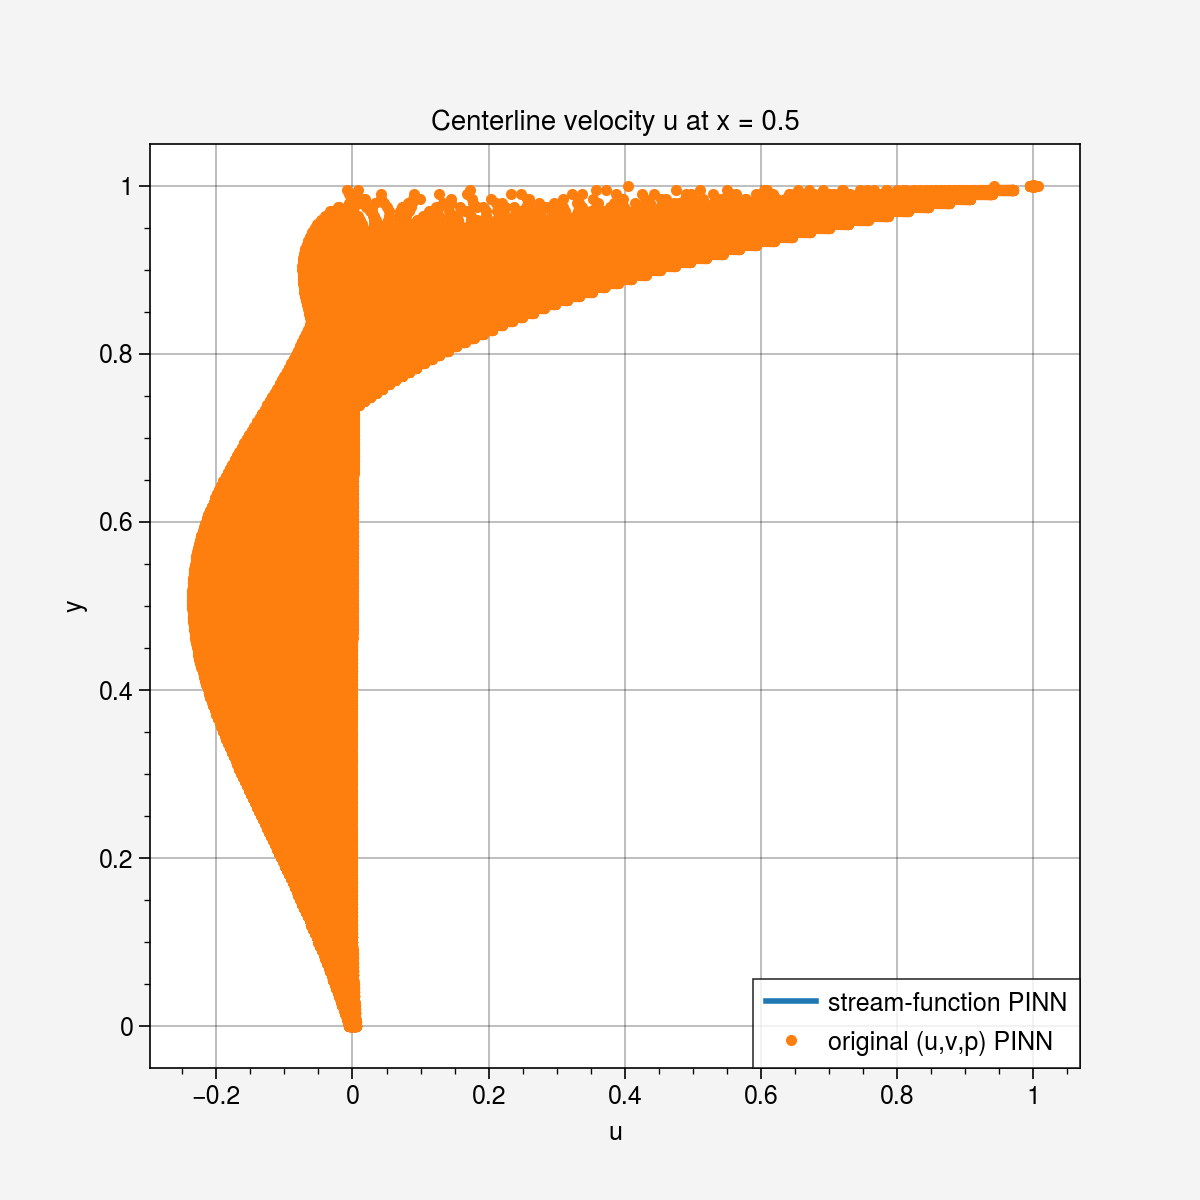

Saved comparison -> c:\Users\thamm\OneDrive\Documents\1 - Projects\0 - STEM\2 - Numerical Physics\9 - PINNs\pinn-deepflow\EXPERIMENTS\cavity_flow_streamfunction\output\compare_centerline_u.png


In [15]:
# Optional: overlay the u-profile on the vertical centerline
import matplotlib.pyplot as plt

if (pathlib.Path("../../examples/cavity_flow_steady/outlet_velocity.txt")).exists():
    ref = np.loadtxt("../../examples/cavity_flow_steady/outlet_velocity.txt")
    ref_y, ref_u = ref[:, 1], ref[:, 2]
    plt.figure(figsize=(6, 6))
    plt.plot(centerline[:, 1], centerline[:, 0], label="stream-function PINN", lw=2)
    plt.plot(ref_u, ref_y, "o", ms=3, label="original (u,v,p) PINN")
    plt.xlabel("u")
    plt.ylabel("y")
    plt.title("Centerline velocity u at x = 0.5")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(OUT_DIR / "compare_centerline_u.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved comparison ->", OUT_DIR / "compare_centerline_u.png")
else:
    print("Original example output not found; skipping comparison plot.")